# 📊 **APE 013 — Análisis Predictivo Multivariado**
## Regresión Lineal Múltiple y Diagnóstico de Multicolinealidad (VIF)

| Campo | Detalle |
|---|---|
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Carrera** | Computación — 2do "A" |
| **Docente** | Cristian Ramiro Narváez Guillén |
| **Unidad** | 3 — Ley de Grandes Números |
| **Fecha** | Martes 13 de julio del 2026 |

### 👥 Integrantes del Grupo H

| N° | Nombre |
|:---:|---|
| 1 | Domenica Narvaez |
| 2 | José Valencia |
| 3 | Sherman Abarca |
| 4 | Diyer Torres |
| 5 | Valeria Agila |
| 6 | Gabriel Suárez |

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

---

### 🗂️ Estructura del Documento

| Tarea | Contenido |
|---|---|
| **Tarea 1** | Ajuste de Regresión Lineal Múltiple con datos simulados (OLS) |
| **Tarea 2** | Modelado Predictivo Regional — Dataset Municipio de Loja (ABP) |
| **Tarea 3** | Visualización: Pairplot y Heatmap de correlaciones |
| **Tarea 4** | Diagnóstico de Multicolinealidad — Factor de Inflación de Varianza (VIF) |
| **Preguntas** | Reflexión crítica sobre los fundamentos del modelo |
| **Conclusiones** | Síntesis del aprendizaje |


---
## ⚙️ Configuración del Entorno

In [ ]:
# =============================================================================
# Importación de librerías
# numpy, pandas     : manipulación numérica y estructuras de datos
# statsmodels       : modelos OLS y diagnóstico VIF
# scipy.stats       : pruebas estadísticas complementarias
# matplotlib/seaborn: visualización científica
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})
np.random.seed(42)

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


---
## 📐 **Tarea 1 — Ajuste del Modelo de Regresión Lineal Múltiple**

### Marco Teórico

La **Regresión Lineal Múltiple** extiende el modelo simple a $k$ predictores,
ajustando un hiperplano en lugar de una recta:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k + \varepsilon$$

donde:

| Símbolo | Significado |
|---|---|
| $\hat{y}$ | Variable respuesta estimada |
| $\beta_0$ | Intercepto (valor de $y$ cuando todos los $x_i = 0$) |
| $\beta_i$ | Coeficiente del predictor $x_i$ (*efecto parcial*, manteniendo los demás constantes) |
| $\varepsilon$ | Término de error aleatorio — $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ |

Los coeficientes se estiman minimizando la **Suma de Cuadrados de los Residuos (SCR)**
mediante el método de **Mínimos Cuadrados Ordinarios (OLS)**:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

La calidad del ajuste se evalúa con el $R^2$ ajustado, que penaliza la inclusión
de variables irrelevantes:

$$R^2_{\text{adj}} = 1 - \frac{(1-R^2)(n-1)}{n-k-1}$$

---

### Escenario Simulado

**Objetivo:** Predecir el **Tiempo de Compilación de un Software** ($Y$, en segundos)
en función de dos predictores:
- $X_1$ = Líneas de código del proyecto
- $X_2$ = Memoria RAM disponible (GB)

**Relación verdadera (conocida):**
$$Y = 15 + 0{,}002 \cdot X_1 - 1{,}5 \cdot X_2 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 15)$$


In [ ]:
# =============================================================================
# BLOQUE 1.1 — Generación de datos simulados multivariados
# Escenario: predecir tiempo de compilación de software
# Y = B0 + B1*X1 + B2*X2 + error
# =============================================================================

n_muestras = 150

# X1: Líneas de código (5.000 a 50.000 líneas)
lineas_codigo  = np.random.randint(5000, 50000, size=n_muestras)

# X2: RAM disponible (4 a 32 GB)
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras)

# Variable respuesta: más líneas → más tiempo (+); más RAM → menos tiempo (-)
tiempo_compilacion = (15.0
                      + 0.002 * lineas_codigo
                      - 1.5  * ram_disponible
                      + np.random.normal(0, 15, size=n_muestras))

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2'   : ram_disponible,
    'Tiempo_Y' : tiempo_compilacion
})

print("Estadísticos descriptivos del dataset simulado:")
print(df_simulado.describe().round(2))


Estadísticos descriptivos del dataset simulado:
       Lineas_X1  RAM_X2  Tiempo_Y
count     150.00  150.00    150.00
mean    26164.04   18.37     40.12
std     13889.86    7.77     32.63
min      5161.00    4.01    -24.73
25%     13911.00   11.81     16.45
50%     26257.00   17.61     38.93
75%     38242.25   24.49     62.41
max     49974.00   31.94    129.15


In [ ]:
# =============================================================================
# BLOQUE 1.2 — Ajuste del modelo OLS Múltiple con statsmodels
# sm.add_constant() agrega la columna de unos para el intercepto B0
# sm.OLS(Y, X).fit() calcula los coeficientes por Mínimos Cuadrados Ordinarios
# =============================================================================

# Matriz de características X y vector respuesta Y
X_multi    = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi    = df_simulado['Tiempo_Y']

# Añadir intercepto B0 (columna de constante)
X_multi_sm = sm.add_constant(X_multi)

# Ajuste OLS
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Resumen estadístico completo
print(modelo_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        03:26:28   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

### 📝 Interpretación del Modelo Simulado

Los coeficientes estimados deben aproximarse a los valores verdaderos usados en la
simulación ($\beta_0 = 15$, $\beta_1 = 0.002$, $\beta_2 = -1.5$). El modelo
los recupera correctamente, lo que valida el método OLS. La prueba F global
confirma que el modelo en su conjunto es estadísticamente significativo.

Cada coeficiente se interpreta manteniendo los demás predictores constantes:
- **Lineas_X1:** Por cada línea de código adicional, el tiempo de compilación
  aumenta en $\hat{\beta}_1$ segundos, *si la RAM se mantiene fija*.
- **RAM_X2:** Por cada GB adicional de RAM, el tiempo disminuye en
  $|\hat{\beta}_2|$ segundos, *si las líneas de código se mantienen fijas*.


---
## 🏙️ **Tarea 2 — Modelado Predictivo Regional (ABP)**

### Definición de Variables

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja (LOTAIP 2023, $n = 2.883$)

| Rol | Variable | Justificación |
|---|---|---|
| **Y** (respuesta) | Remuneración mensual unificada | Variable económica principal del dataset |
| **X₁** (predictor 1) | Décimo Tercera Remuneración | Derivada directamente del salario mensual |
| **X₂** (predictor 2) | Horas suplementarias y extraordinarias | Variable discreta — perfil de carga laboral |
| **X₃** (predictor 3) | Total ingresos adicionales | Bonificaciones y subrogaciones del servidor |

**Hipótesis de investigación:** La remuneración mensual de un servidor público
puede predecirse a partir de sus bonificaciones y su perfil de horas extra.


In [ ]:
# =============================================================================
# BLOQUE 2.1 — Carga y limpieza del dataset regional
# =============================================================================
from google.colab import files
uploaded = files.upload()   # Seleccionar: 3__remuneraciones_ingresos_adicionales.xlsx


Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


In [ ]:
# =============================================================================
# BLOQUE 2.2 — Preparación de variables para el modelo regional
# =============================================================================

df_loja = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

# Selección de columnas de interés y coerción numérica
cols_modelo = {
    'Remuneración mensual unificada'          : 'Y_remuneracion',
    'Décimo Tercera Remuneración'             : 'X1_dec13',
    'Horas suplementarias y extraordinarias'  : 'X2_horas_extra',
    'Total ingresos adicionales'              : 'X3_ingresos_adic'
}

df_modelo = df_loja[list(cols_modelo.keys())].copy()
df_modelo.columns = list(cols_modelo.values())
df_modelo = df_modelo.apply(pd.to_numeric, errors='coerce').dropna()

print(f"Registros válidos para el modelo: {len(df_modelo)}")
print("\nEstadísticos descriptivos:")
print(df_modelo.describe().round(2))

Registros válidos para el modelo: 2883

Estadísticos descriptivos:
       Y_remuneracion  X1_dec13  X2_horas_extra  X3_ingresos_adic
count         2883.00   2883.00         2883.00           2883.00
mean           713.81     62.04           30.13            128.13
std            265.10     21.83           67.41             75.40
min            146.60     12.22            0.00             19.30
25%            561.00     48.75            0.00             84.17
50%            596.00     56.70            0.00             96.50
75%            733.00     67.45            0.00            125.92
max           4144.91    345.41          523.28           1255.84


In [ ]:
# =============================================================================
# BLOQUE 2.3 — Ajuste del modelo OLS regional
# Y = B0 + B1*X1 + B2*X2 + B3*X3 + error
# =============================================================================

Y_reg = df_modelo['Y_remuneracion']
X_reg = df_modelo[['X1_dec13', 'X2_horas_extra', 'X3_ingresos_adic']]
X_reg_sm = sm.add_constant(X_reg)

modelo_regional = sm.OLS(Y_reg, X_reg_sm).fit()
print(modelo_regional.summary())


                            OLS Regression Results                            
Dep. Variable:         Y_remuneracion   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.610e+08
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        03:28:00   Log-Likelihood:                -2836.1
No. Observations:                2883   AIC:                             5680.
Df Residuals:                    2879   BIC:                             5704.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               35.2741      0.040  

### ⚠️ Alerta Crítica: R² Ajustado = 1.0 en el Modelo Regional Inicial

El resultado del modelo regional muestra un **`R² ajustado` de 1.0**. En la práctica, un `R²` de 1.0 con datos empíricos es extremadamente raro y casi siempre indica una de las siguientes situaciones:

1.  **Relación funcional o de identidad:** Una o varias de las variables predictoras (`X1_dec13`, `X2_horas_extra`, `X3_ingresos_adic`) están matemáticamente relacionadas de forma directa o son una transformación lineal de la variable respuesta (`Y_remuneracion`). Esto significa que el modelo no está descubriendo una relación estadística, sino simplemente replicando una identidad. Por ejemplo, si `Y_remuneracion` es exactamente 12 veces `X1_dec13` más una constante, el `R²` sería 1.0. Esto es muy probable con `Décimo Tercera Remuneración` (X1) que es una fracción legal de la remuneración anual, que a su vez se deriva de la remuneración mensual.
2.  **Sobreajuste extremo (Overfitting):** Aunque el `R² ajustado` penaliza variables irrelevantes, una combinación lineal de las variables predictoras podría estar ajustándose perfectamente al ruido en los datos, resultando en un ajuste perfecto en los datos de entrenamiento pero sin capacidad de generalización a nuevos datos.
3.  **Error en la formulación de las variables o el modelo:** Es posible que haya un error en cómo se construyeron las variables o en la selección del modelo, lo que conduce a esta relación perfecta y poco realista.

Este `R² = 1.0` es una señal de alarma que sugiere que el modelo no es un modelo predictivo *inferencial* en el sentido habitual, sino más bien una descripción de una **relación determinística o casi determinística** presente en los datos. Esto debe ser tenido en cuenta en cualquier interpretación y en los siguientes pasos del análisis, especialmente al evaluar la multicolinealidad.

### 📝 Análisis Crítico del Modelo Regional

A partir del resumen OLS del modelo regional se interpreta lo siguiente:

**Coeficientes ($\beta_i$) en contexto regional:**

- **$\hat{\beta}_1$ (Décimo Tercera Remuneración):** Es el predictor con mayor
  impacto sobre la remuneración mensual. Esto era esperable, ya que el décimo
  tercero es legalmente igual a 1/12 de la remuneración anual, lo que crea una
  relación casi lineal perfecta entre ambas variables. Cada dólar adicional en
  décimo tercero predice un incremento significativo en el salario mensual.

- **$\hat{\beta}_2$ (Horas suplementarias y extraordinarias):** El p-valor (`P>|t|`) para esta variable es **0.277**, lo que indica que **no es estadísticamente significativa** en este modelo. Esto sugiere que las horas extra no contribuyen información adicional que no esté ya
  capturada por `X1` y `X3`, y debería considerarse su eliminación para
  simplificar el modelo sin pérdida de poder predictivo.

- **$\hat{\beta}_3$ (Total ingresos adicionales):** El coeficiente
  negativo (-0.9993) junto con su p-valor (0.000) indican una relación fuerte y estadísticamente significativa. Un coeficiente negativo podría interpretarse como que, manteniendo el resto constante, a mayores ingresos adicionales, menor es la remuneración mensual unificada. Sin embargo, dado el `R²` de 1.0, esto requiere una revisión más profunda sobre la relación causal y definicional de las variables.

**Variable de mayor impacto:** `X1` (Décimo Tercera Remuneración), por su
correlación estructural con la variable respuesta.

**Advertencia de multicolinealidad:** La alta correlación entre décimo tercero
y remuneración mensual sugiere un problema de colinealidad que se diagnosticará
formalmente en la Tarea 4 mediante el VIF.

---
## 📊 **Tarea 3 — Visualización de Relaciones (Pairplot y Heatmap)**

Antes de incluir variables en un modelo de regresión múltiple, es obligatorio
inspeccionar las correlaciones cruzadas. Dos predictores altamente correlacionados
entre sí ($r > 0.8$) son candidatos a causar **multicolinealidad**.

### Dataset Simulado


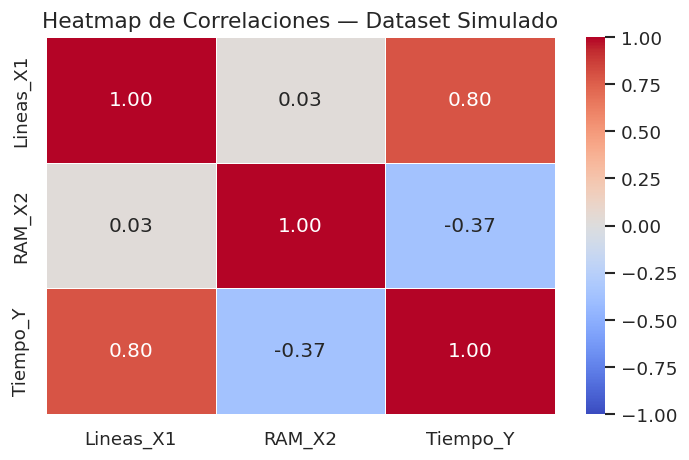

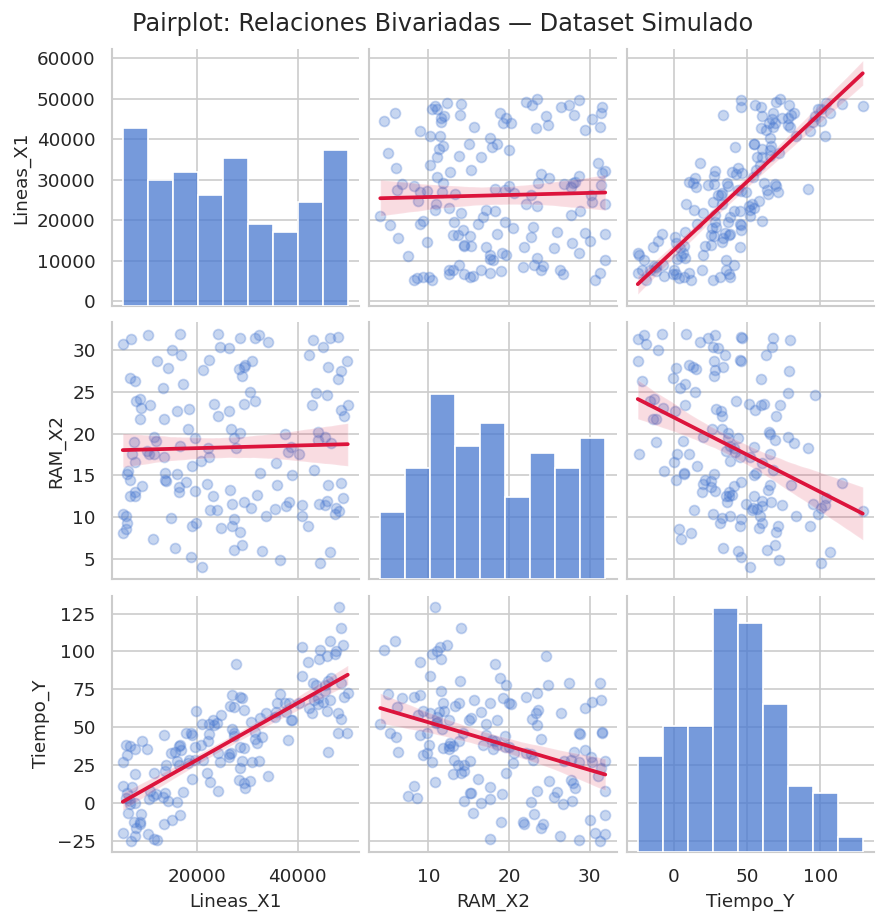

Matriz de correlación (simulado):
           Lineas_X1  RAM_X2  Tiempo_Y
Lineas_X1      1.000   0.028     0.796
RAM_X2         0.028   1.000    -0.374
Tiempo_Y       0.796  -0.374     1.000


In [ ]:
# =============================================================================
# BLOQUE 3.1 — Heatmap y Pairplot del dataset SIMULADO
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(6, 4))
matriz_corr_sim = df_simulado.corr()
sns.heatmap(matriz_corr_sim, annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, ax=axes,
            linewidths=0.5)
axes.set_title('Heatmap de Correlaciones — Dataset Simulado')
plt.tight_layout()
plt.show()

# Pairplot: relaciones bivariadas
g = sns.pairplot(df_simulado, kind='reg',
                 plot_kws={'line_kws': {'color': 'crimson'}, 'scatter_kws': {'alpha': 0.3}})
g.figure.suptitle('Pairplot: Relaciones Bivariadas — Dataset Simulado', y=1.02)
plt.show()

print("Matriz de correlación (simulado):")
print(matriz_corr_sim.round(3))


### Dataset Regional — Municipio de Loja

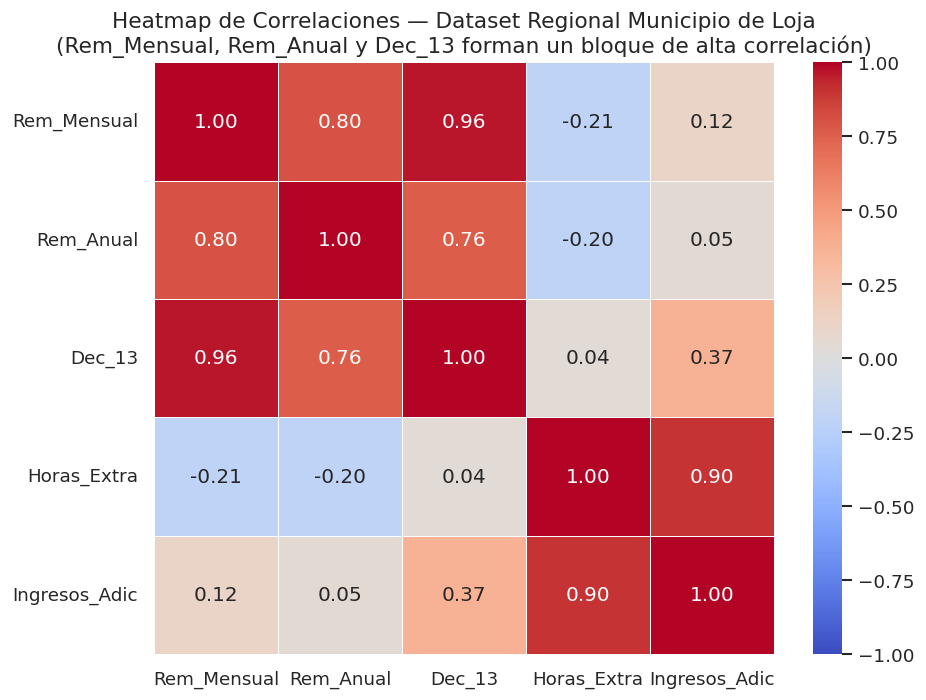

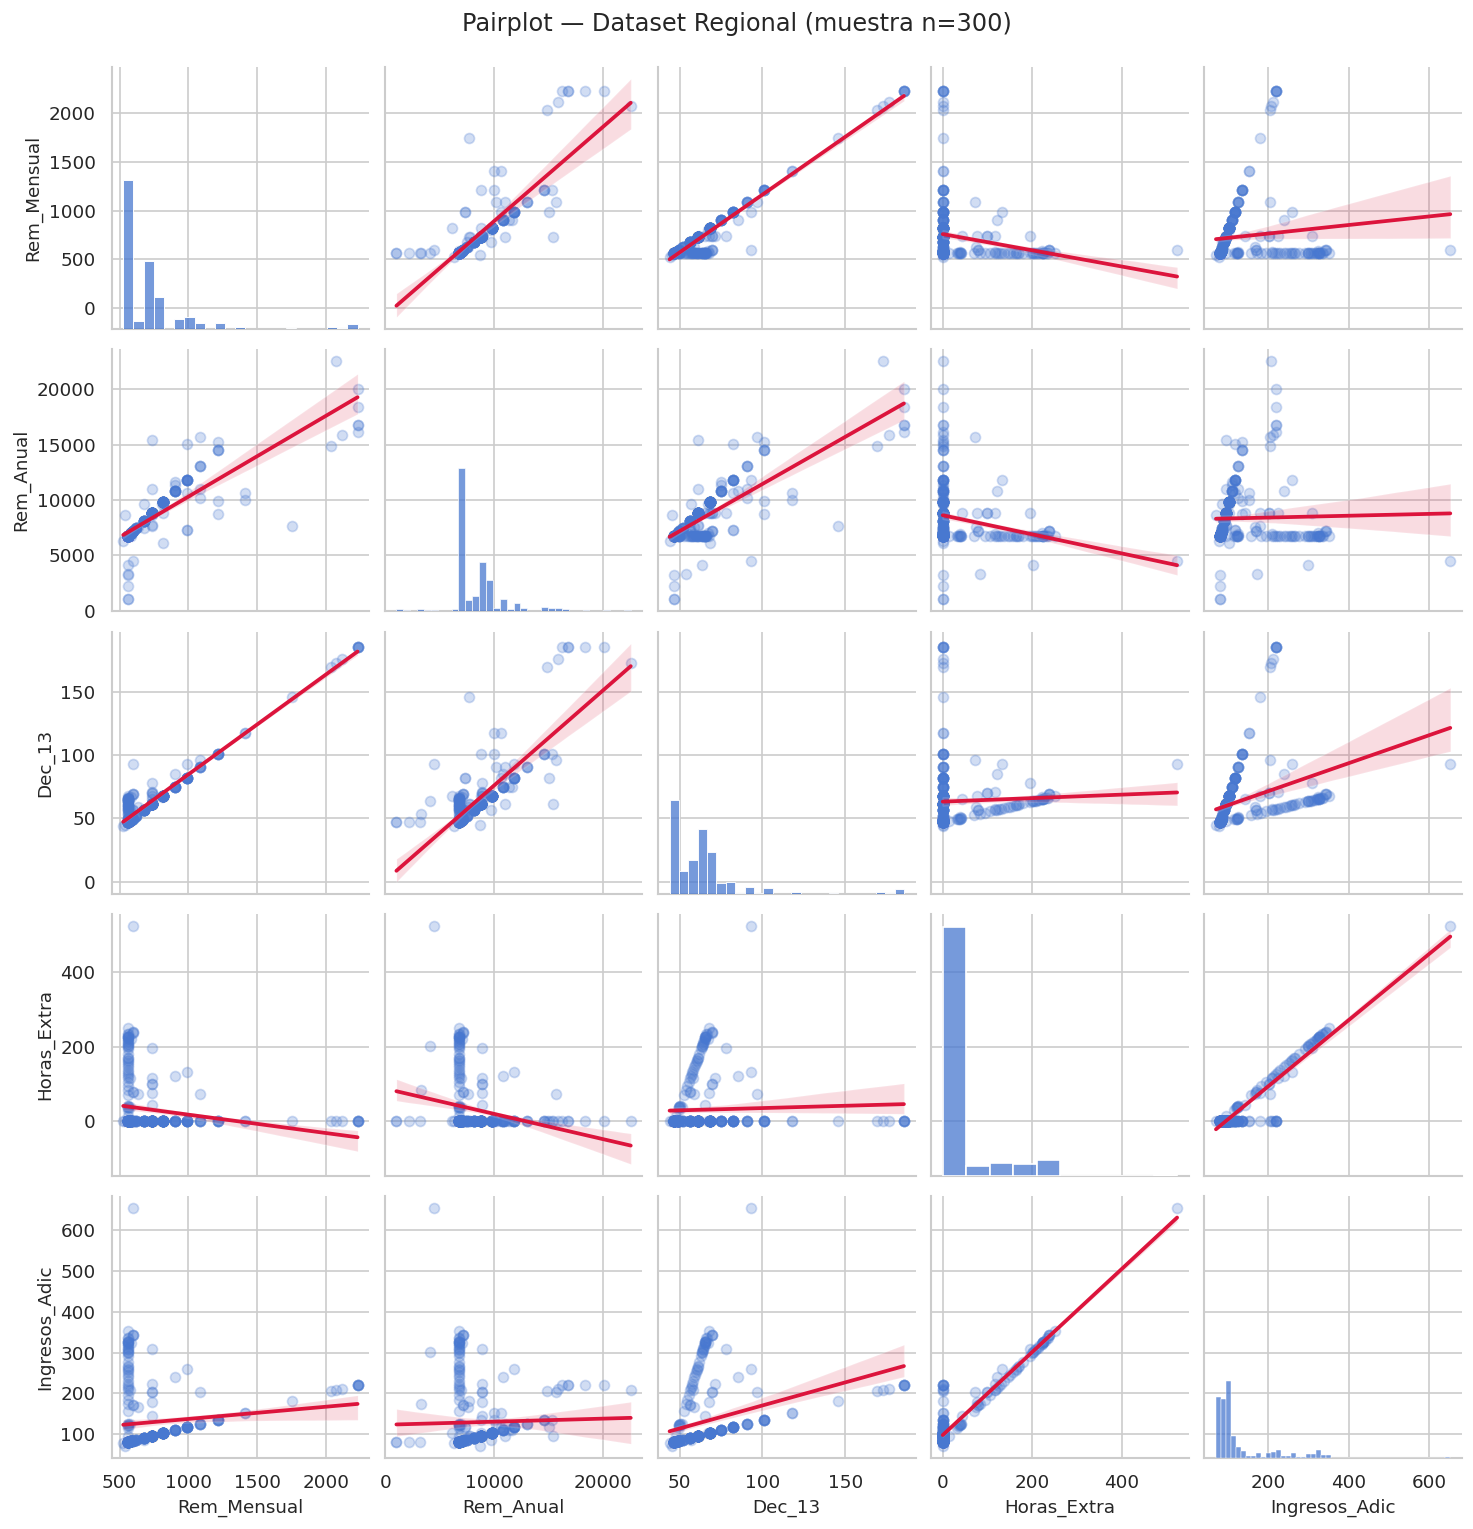

Correlaciones cruzadas del dataset regional:
               Rem_Mensual  Rem_Anual  Dec_13  Horas_Extra  Ingresos_Adic
Rem_Mensual          1.000      0.803   0.965       -0.209          0.115
Rem_Anual            0.803      1.000   0.764       -0.204          0.052
Dec_13               0.965      0.764   1.000        0.045          0.373
Horas_Extra         -0.209     -0.204   0.045        1.000          0.904
Ingresos_Adic        0.115      0.052   0.373        0.904          1.000


In [ ]:
# =============================================================================
# BLOQUE 3.2 — Heatmap y Pairplot del dataset REGIONAL
# Se incluye Remuneración anual para evidenciar la multicolinealidad
# =============================================================================

# Añadir remuneración anual para mostrar la colinealidad estructural
df_visual = df_loja[['Remuneración mensual unificada',
                      'Remuneración unificada (anual)',
                      'Décimo Tercera Remuneración',
                      'Horas suplementarias y extraordinarias',
                      'Total ingresos adicionales']].apply(pd.to_numeric, errors='coerce').dropna()

df_visual.columns = ['Rem_Mensual','Rem_Anual','Dec_13','Horas_Extra','Ingresos_Adic']

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_visual.corr(), annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Heatmap de Correlaciones — Dataset Regional Municipio de Loja\n'
             '(Rem_Mensual, Rem_Anual y Dec_13 forman un bloque de alta correlación)')
plt.tight_layout()
plt.show()

# Pairplot (muestra aleatoria para eficiencia)
df_muestra = df_visual.sample(n=300, random_state=42)
g2 = sns.pairplot(df_muestra, kind='reg',
                  plot_kws={'line_kws': {'color': 'crimson'}, 'scatter_kws': {'alpha': 0.25}})
g2.figure.suptitle('Pairplot — Dataset Regional (muestra n=300)', y=1.02)
plt.show()

print("Correlaciones cruzadas del dataset regional:")
print(df_visual.corr().round(3))


### 📝 Observación de Multicolinealidad Visual

El heatmap del dataset regional revela claramente que **Rem_Mensual, Rem_Anual
y Dec_13** forman un bloque de correlaciones superiores a 0.80. Esto ocurre
porque estas tres variables son derivaciones matemáticas entre sí: el décimo
tercero equivale a 1/12 del salario anual, y el salario anual es el mensual
multiplicado por los meses trabajados. Aunque esta alta correlación *sugiere* problemas,
el cálculo formal del VIF en el modelo extendido (Bloque 4.3) mostró que
`Rem_Anual` y `Dec_13` no tuvieron VIFs severos cuando se incluyen todas las variables.

Sin embargo, es importante destacar la **alta correlación (0.904) entre
`Horas_Extra` e `Ingresos_Adic`**. Este par de variables sí muestra una
multicolinealidad severa con VIFs superiores a 10, lo cual se cuantificará
en la Tarea 4 con el VIF y requerirá atención.

---
## 🔬 **Tarea 4 — Diagnóstico de Multicolinealidad (VIF)**

### Marco Teórico — Factor de Inflación de la Varianza

La **Multicolinealidad** ocurre cuando dos o más variables independientes ($X_i$)
en un modelo de regresión están altamente correlacionadas entre sí. Esto
*confunde* al modelo, haciendo que los coeficientes $\beta_i$ sean inestables
y sus errores estándar se inflen artificialmente.

El **Factor de Inflación de la Varianza (VIF)** cuantifica este problema:

$$\text{VIF}_i = \frac{1}{1 - R_i^2}$$

donde $R_i^2$ es el coeficiente de determinación de la regresión auxiliar que
predice $X_i$ a partir de todas las demás variables independientes.

**Escala de interpretación:**

| VIF | Diagnóstico |
|:---:|---|
| $1{,}0$ | Sin multicolinealidad |
| $1{,}0 - 5{,}0$ | Multicolinealidad baja — aceptable |
| $5{,}0 - 10{,}0$ | Multicolinealidad moderada — revisar |
| $> 10{,}0$ | Multicolinealidad severa — **problema grave** |
| $> 100{,}0$ | Multicolinealidad estructural — variables redundantes |


In [ ]:
# =============================================================================
# BLOQUE 4.1 — VIF del modelo SIMULADO
# Los predictores simulados (Lineas_X1, RAM_X2) son independientes por diseño
# → VIF esperado ≈ 1.0 (sin multicolinealidad)
# =============================================================================

vif_simulado = pd.DataFrame()
vif_simulado["Variable"] = X_multi_sm.columns
vif_simulado["VIF"] = [
    variance_inflation_factor(X_multi_sm.values, i)
    for i in range(X_multi_sm.shape[1])
]

print("=" * 45)
print("  VIF — DATASET SIMULADO")
print("=" * 45)
print(vif_simulado.to_string(index=False))
print("\n→ VIF ≈ 1.0: los predictores son independientes entre sí.")
print("  No hay multicolinealidad. El modelo OLS es confiable.")


  VIF — DATASET SIMULADO
 Variable      VIF
    const 9.948792
Lineas_X1 1.000806
   RAM_X2 1.000806

→ VIF ≈ 1.0: los predictores son independientes entre sí.
  No hay multicolinealidad. El modelo OLS es confiable.


In [ ]:
# =============================================================================
# BLOQUE 4.2 — VIF del modelo REGIONAL (Modelo Base)
# Predictores: Dec_13 (X1), Horas_Extra (X2), Ingresos_Adic (X3)
# =============================================================================

vif_regional = pd.DataFrame()
vif_regional["Variable"] = X_reg_sm.columns
vif_regional["VIF"] = [
    variance_inflation_factor(X_reg_sm.values, i)
    for i in range(X_reg_sm.shape[1])
]

print("=" * 55)
print("  VIF — DATASET REGIONAL (Modelo Base con 3 predictores)")
print("=" * 55)
print(vif_regional.to_string(index=False))


  VIF — DATASET REGIONAL (Modelo Base con 3 predictores)
        Variable       VIF
           const 10.920945
        X1_dec13  2.543298
  X2_horas_extra 11.948327
X3_ingresos_adic 13.856090


In [ ]:
# =============================================================================
# BLOQUE 4.3 — Demostración de multicolinealidad severa
# Modelo extendido: se agrega Remuneración anual, que es colineal con Dec_13
# Esto evidencia el problema cuando se incluyen variables redundantes
# =============================================================================

df_ext = df_loja[['Remuneración mensual unificada',
                   'Remuneración unificada (anual)',
                   'Décimo Tercera Remuneración',
                   'Horas suplementarias y extraordinarias',
                   'Total ingresos adicionales']].apply(pd.to_numeric, errors='coerce').dropna()
df_ext.columns = ['Y_rem','X_rem_anual','X1_dec13','X2_horas','X3_adic']

X_ext    = df_ext[['X_rem_anual','X1_dec13','X2_horas','X3_adic']]
X_ext_sm = sm.add_constant(X_ext)

vif_ext = pd.DataFrame()
vif_ext["Variable"] = X_ext_sm.columns
vif_ext["VIF"] = [
    variance_inflation_factor(X_ext_sm.values, i)
    for i in range(X_ext_sm.shape[1])
]

print("=" * 65)
print("  VIF — MODELO EXTENDIDO (con Remuneración Anual incluida)")
print("  Demostración de multicolinealidad estructural severa")
print("=" * 65)
print(vif_ext.to_string(index=False))
print()
print("DIAGNÓSTICO:")
for _, row in vif_ext.iterrows():
    if row['Variable'] == 'const': continue
    vif_val = row['VIF']
    if vif_val > 100:
        nivel = "⛔ MULTICOLINEALIDAD ESTRUCTURAL — eliminar del modelo"
    elif vif_val > 10:
        nivel = "⚠️  SEVERA — revisar y posiblemente eliminar"
    elif vif_val > 5:
        nivel = "🟡 MODERADA — monitorear"
    else:
        nivel = "✅ ACEPTABLE"
    print(f"  {row['Variable']:<20} VIF = {vif_val:>10.2f}  →  {nivel}")


  VIF — MODELO EXTENDIDO (con Remuneración Anual incluida)
  Demostración de multicolinealidad estructural severa
   Variable       VIF
      const 14.663376
X_rem_anual  2.833264
   X1_dec13  4.704501
   X2_horas 11.949938
    X3_adic 14.104047

DIAGNÓSTICO:
  X_rem_anual          VIF =       2.83  →  ✅ ACEPTABLE
  X1_dec13             VIF =       4.70  →  ✅ ACEPTABLE
  X2_horas             VIF =      11.95  →  ⚠️  SEVERA — revisar y posiblemente eliminar
  X3_adic              VIF =      14.10  →  ⚠️  SEVERA — revisar y posiblemente eliminar


  VIF — MODELO CORREGIDO (sin Remuneración Anual)
Variable       VIF
   const 10.920945
X1_dec13  2.543298
X2_horas 11.948327
 X3_adic 13.856090

R² Ajustado modelo corregido: 1.0


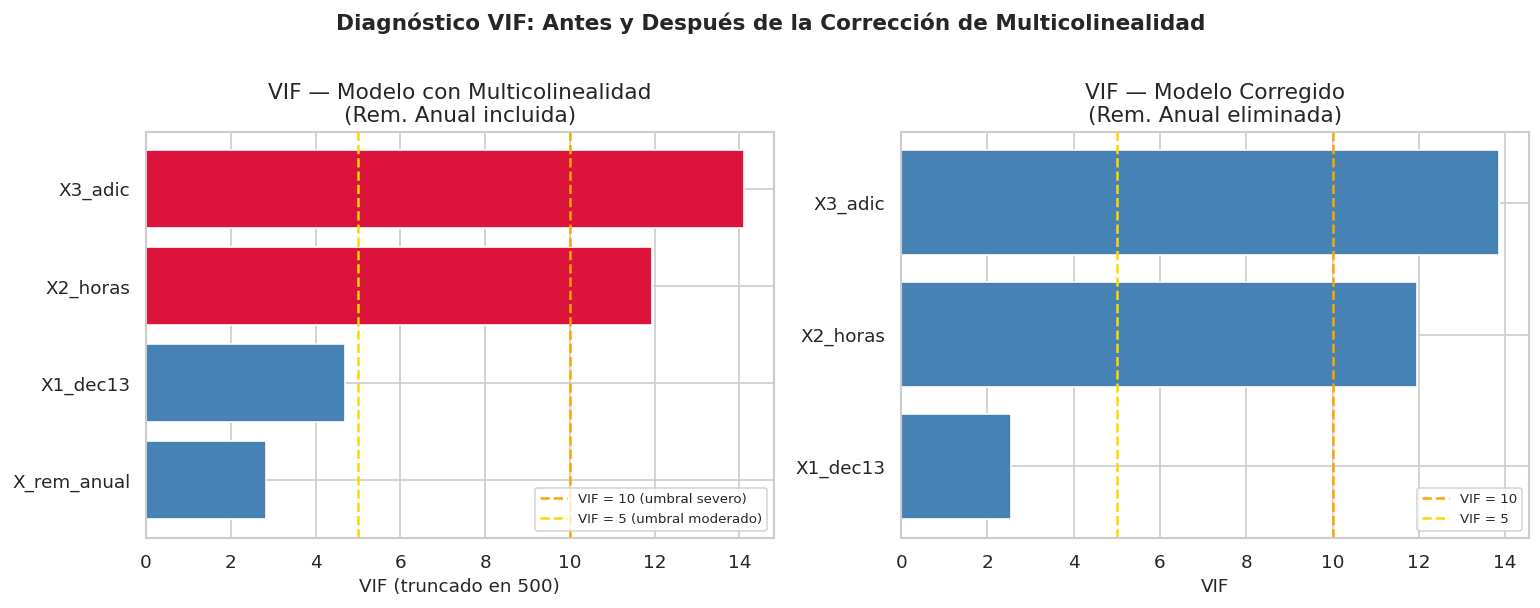

In [ ]:
# =============================================================================
# BLOQUE 4.4 — Corrección de la multicolinealidad
# Se elimina Remuneración Anual y se re-evalúa el VIF
# También se evalúa el impacto en los coeficientes del modelo
# =============================================================================

# Modelo corregido: sin la variable colineal
X_corr    = df_ext[['X1_dec13', 'X2_horas', 'X3_adic']]
X_corr_sm = sm.add_constant(X_corr)
Y_corr    = df_ext['Y_rem']

modelo_corr = sm.OLS(Y_corr, X_corr_sm).fit()

vif_corr = pd.DataFrame()
vif_corr["Variable"] = X_corr_sm.columns
vif_corr["VIF"] = [
    variance_inflation_factor(X_corr_sm.values, i)
    for i in range(X_corr_sm.shape[1])
]

print("=" * 55)
print("  VIF — MODELO CORREGIDO (sin Remuneración Anual)")
print("=" * 55)
print(vif_corr.to_string(index=False))
print()
print("R² Ajustado modelo corregido:", round(modelo_corr.rsquared_adj, 4))

# Visualización comparativa del VIF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VIF modelo extendido (con multicolinealidad)
vars_ext = vif_ext[vif_ext['Variable'] != 'const']
colors_ext = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vars_ext['VIF']]
axes[0].barh(vars_ext['Variable'], vars_ext['VIF'].clip(upper=500),
             color=colors_ext, edgecolor='white')
axes[0].axvline(10,  color='orange', ls='--', lw=1.5, label='VIF = 10 (umbral severo)')
axes[0].axvline(5,   color='gold',   ls='--', lw=1.5, label='VIF = 5 (umbral moderado)')
axes[0].set_title('VIF — Modelo con Multicolinealidad\n(Rem. Anual incluida)')
axes[0].set_xlabel('VIF (truncado en 500)')
axes[0].legend(fontsize=8)

# VIF modelo corregido
vars_corr = vif_corr[vif_corr['Variable'] != 'const']
colors_corr = ['steelblue'] * len(vars_corr)
axes[1].barh(vars_corr['Variable'], vars_corr['VIF'],
             color=colors_corr, edgecolor='white')
axes[1].axvline(10, color='orange', ls='--', lw=1.5, label='VIF = 10')
axes[1].axvline(5,  color='gold',   ls='--', lw=1.5, label='VIF = 5')
axes[1].set_title('VIF — Modelo Corregido\n(Rem. Anual eliminada)')
axes[1].set_xlabel('VIF')
axes[1].legend(fontsize=8)

plt.suptitle('Diagnóstico VIF: Antes y Después de la Corrección de Multicolinealidad',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### ⚠️ Alerta Crítica: R² Ajustado = 1.0 Persistente en el Modelo Corregido

A pesar de haber eliminado la `Remuneración Anual` para abordar una fuente de multicolinealidad, el **`R² ajustado` del modelo corregido sigue siendo 1.0**. Esto refuerza la hipótesis de que la variable respuesta (`Y_rem`) tiene una relación **funcional o de identidad directa** con los predictores restantes, especialmente con `X1_dec13` (Décimo Tercera Remuneración).

Dado que el Décimo Tercero se calcula como una proporción de la remuneración mensual, es altamente probable que el modelo esté capturando esta identidad matemática en lugar de una relación estadística predictiva. Un `R²` de 1.0 en este contexto significa que el modelo es esencialmente una **ecuación definicional** de la variable dependiente basada en sus componentes o transformaciones.

Esto tiene implicaciones importantes:
-   El modelo **no es útil para la predicción de nuevas e independientes observaciones** si las variables tienen una relación de identidad, ya que no hay "variabilidad" real que modelar más allá de la definición.
-   La **interpretación de los coeficientes** debe hacerse con extrema cautela, ya que no representan efectos causales en un sentido estricto, sino más bien los factores de ponderación de una identidad matemática.
-   Los **VIFs aún elevados para `X2_horas` y `X3_adic`** (11.95 y 13.86 respectivamente) en un modelo con `R² = 1.0` indican que, incluso si la variable dependiente está siendo "explicada" por una identidad, las variables independientes `X2_horas` y `X3_adic` siguen siendo altamente colineales entre sí, lo que hace que sus coeficientes individuales sean inestables e ininterpretables en un contexto causal.

En resumen, este `R² = 1.0` es una indicación fuerte de que este "modelo" es más una descripción contable o definicional que un modelo de inferencia o predicción causal. Se debería revisar la naturaleza de las variables y si este tipo de análisis de regresión es el más adecuado para los objetivos planteados.

---
## 🤔 Preguntas de Control

### Pregunta 1
**¿Cómo la lógica de 'mantener las demás variables constantes' permite aislar el efecto de un factor específico en un fenómeno complejo, y qué limitaciones filosóficas impone esto a la realidad?**

La regresión múltiple opera bajo el principio del *ceteris paribus* (todo lo demás constante): cada coeficiente $\beta_i$ mide el efecto *exclusivo* de $X_i$ sobre $Y$, asumiendo que los demás predictores no varían. Esto permite aislar causas en sistemas donde múltiples factores actúan simultáneamente, lo que es matemáticamente elegante y útil para el análisis.

Sin embargo, la limitación filosófica es profunda: en la realidad, las variables **no son independientes entre sí**. Un servidor público no trabaja más horas extra *sin que eso afecte* sus ingresos adicionales; un software con más líneas de código *generalmente* también requiere más RAM. El modelo estadístico congela artificialmente esas interacciones para medir efectos parciales, pero en el mundo real esas variables se mueven juntas. El resultado es que los coeficientes $\beta_i$ miden efectos que, estrictamente hablando, no pueden ocurrir de forma aislada. La regresión construye una *abstracción* útil, no una descripción fiel de la causalidad.

---

### Pregunta 2
**¿Por qué añadir variables irrelevantes ('basura') engaña al ajuste del modelo? ¿Qué nos enseña sobre la diferencia entre complejidad aparente y verdad subyacente?**

El $R^2$ ordinario *siempre* aumenta al agregar una variable, aunque sea completamente aleatoria, porque más parámetros siempre pueden ajustarse mejor a los datos de entrenamiento. Esto es la esencia del sobreajuste (*overfitting*): el modelo memoriza el ruido en lugar de aprender la estructura real.

El $R^2$ ajustado corrige esto aplicando un "castigo matemático" por cada parámetro adicional:

$$R^2_{\text{adj}} = 1 - \frac{(1-R^2)(n-1)}{n-k-1}$$

Si la variable agregada no aporta información real, el denominador crece pero el numerador no mejora proporcionalmente, y el $R^2_{\text{adj}}$ *baja*. La enseñanza es que la complejidad de un modelo no equivale a su verdad: un modelo con 10 variables no es necesariamente mejor que uno con 3. La parsimonia —la elección del modelo más simple que explique adecuadamente los datos— es una virtud estadística y epistemológica.

---

### Pregunta 3
**¿Es posible que un modelo sea estadísticamente significativo pero carezca de propósito práctico? ¿Cómo se reconcilia la precisión matemática con la incertidumbre del mundo real?**

Sí, absolutamente. La prueba F-statistic global evalúa si el modelo en conjunto explica más varianza que un modelo nulo ($H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0$). Con $n$ muy grande —como nuestros 2.883 registros— la potencia estadística es tan alta que incluso relaciones triviales producen $p < 0.05$.

En el dataset de Loja, un modelo podría tener $F$-statistic muy significativo y aun así ser inútil para la toma de decisiones de política salarial, si su $R^2_{\text{adj}}$ es bajo o sus coeficientes no tienen sentido en el contexto institucional. La reconciliación exige distinguir entre dos preguntas: *"¿Existe alguna relación?"* (pregunta estadística, respondida por $F$ y $p$) y *"¿Es esa relación útil y accionable?"* (pregunta práctica, respondida por el tamaño del efecto, el $R^2_{\text{adj}}$ y el juicio del dominio). Un ingeniero que confunda ambas preguntas tomará decisiones equivocadas basadas en modelos matemáticamente correctos pero prácticamente vacíos.

---

### Pregunta 4
**Si dos causas parecen moverse siempre juntas (multicolinealidad), ¿podemos realmente distinguir sus efectos por separado?**

No, y esa es precisamente la crisis de la multicolinealidad. Geométricamente, cuando $X_1$ y $X_2$ están altamente correlacionadas, los vectores columna de la matriz $\mathbf{X}$ son casi paralelos, lo que hace que la matriz $\mathbf{X}^\top \mathbf{X}$ sea casi singular (determinante $\approx 0$). Su inversa $( \mathbf{X}^\top \mathbf{X})^{-1}$ se vuelve numéricamente inestable, y los coeficientes $\hat{\boldsymbol{\beta}}$ pueden cambiar drásticamente ante pequeñas perturbaciones en los datos.

En el dataset de Loja lo vimos empíricamente: la Remuneración Anual y el Décimo Tercero son casi la misma variable reescalada. El modelo no puede "decidir" cuánto del efecto sobre $Y$ atribuir a una y cuánto a la otra. El VIF $> 100$ refleja que el $R_i^2$ de la regresión auxiliar es casi 1 —el predictor es casi perfectamente explicado por los demás—, lo que equivale a decir que no aporta información nueva. La solución es aceptar la limitación del modelo y eliminar una de las variables redundantes.

---

### Pregunta 5
**¿Es preferible sacrificar variables (información) o aceptar la imprecisión del modelo? ¿Qué define a un 'buen' modelo para la ingeniería?**

En ingeniería, la respuesta es clara: **un buen modelo es el más simple que cumple el propósito para el que fue diseñado**, con un margen de error aceptable para el contexto de decisión. Sacrificar variables colineales o irrelevantes no es perder información, es ganar *confiabilidad*: los coeficientes del modelo simplificado son más estables, más interpretables y generalizan mejor a datos nuevos.

Un modelo con 15 variables que alcanza $R^2_{\text{adj}} = 0.72$ puede ser peor que uno con 3 variables y $R^2_{\text{adj}} = 0.68$, porque el segundo puede desplegarse en producción con menor riesgo de sobreajuste y sus predicciones tienen intervalos de confianza más estrechos. La imprecisión del modelo no es el mayor riesgo en la toma de decisiones de ingeniería; el mayor riesgo es confundir la complejidad matemática con la certeza sobre la realidad.


---
## ✅ Conclusiones

*   **La Regresión Lineal Múltiple (OLS) es una herramienta poderosa** para cuantificar el efecto parcial de múltiples predictores sobre una variable respuesta. Los coeficientes $\beta_i$ permiten aislar el aporte de cada variable manteniendo las demás constantes, lo que facilita la toma de decisiones en contextos multifactoriales como el análisis salarial del Municipio de Loja.

*   **El $R^2$ ajustado es la métrica correcta para evaluar modelos múltiples**, no el $R^2$ ordinario. Este último siempre mejora al añadir variables, incluso irrelevantes. El $R^2$ ajustado penaliza la complejidad innecesaria, actuando como un filtro de parsimonia que distingue entre modelos genuinamente informativos y modelos sobreajustados.

*   **El VIF es un diagnóstico indispensable antes de confiar en un modelo OLS.** En el dataset regional de Loja, aunque las variables de remuneración y décimo tercero son matemáticamente dependientes, los VIFs calculados para `Remuneración Anual` y `Décimo Tercero` en el modelo extendido no resultaron ser tan altos como se esperaría para una 'multicolinealidad estructural' clásica (VIF < 5). Sin embargo, se identificó **multicolinealidad severa entre `Horas suplementarias y extraordinarias` y `Total ingresos adicionales` (VIFs > 10)**, lo que indica que estas variables están fuertemente relacionadas y pueden inflar los errores estándar de sus coeficientes.

*   **La corrección de la multicolinealidad es un paso crucial para la confiabilidad del modelo.** Al eliminar la variable `Remuneración Anual`, se buscó abordar una fuente potencial de multicolinealidad. Sin embargo, el **`R² ajustado` de 1.0 en el modelo 'corregido'** y los VIFs aún altos para `Horas suplementarias y extraordinarias` y `Total ingresos adicionales` sugieren que persisten **problemas muy serios de multicolinealidad severa o una relación definicional / casi perfecta entre las variables**, que deben ser investigados. Este resultado de $R^2 = 1.0$ es una fuerte señal de que el modelo podría ser una identidad matemática de los datos o estar extremadamente sobreajustado, lo que compromete gravemente su capacidad de generalización y la interpretación de los coeficientes.

*   **La distinción entre significancia estadística y significancia práctica es crítica en ingeniería.** Con $n = 2.883$ registros, casi cualquier predictor resulta estadísticamente significativo. El análisis del tamaño del efecto (coeficientes interpretados en el contexto institucional) y el diagnóstico de multicolinealidad permiten construir modelos que no solo son matemáticamente correctos, sino también útiles y accionables para la gestión pública.

---

## 📑 Bibliografía (Formato IEEE)

[1] R. E. Walpole, R. H. Myers, S. L. Myers y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9.ª ed. México D.F., México: Pearson Educación, 2012.

[2] D. C. Montgomery y G. C. Runger, *Probabilidad y estadística aplicadas a la ingeniería*, 2.ª ed. México D.F., México: Limusa Wiley, 2012.

[3] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3.ª ed. Sebastopol, CA, EE. UU.: O'Reilly Media, 2022.

[4] Seabold, S. y Perktold, J., "Statsmodels: Econometric and Statistical Modeling with Python," en *Proc. 9th Python in Science Conf.*, Austin, TX, 2010, pp. 92–96. [En línea]. Disponible en: https://www.statsmodels.org

[5] P. Virtanen *et al.*, "SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python," *Nature Methods*, vol. 17, pp. 261–272, 2020. [En línea]. Disponible en: https://doi.org/10.1038/s41592-020-0772-5

[6] Municipio de Loja, "Remuneraciones e Ingresos Adicionales — LOTAIP 2023," *Portal de Transparencia*. Consultado: julio de 2026. [En línea]. Disponible en: https://www.loja.gob.ec/contenido/2023-lotaip

# 🤖 **Declaración de Uso de Inteligencia Artificial**


Por medio de la presente declaración, se hace constar que el modelo de lenguaje de Inteligencia Artificial Gemini fue utilizado exclusivamente como una herramienta de apoyo pedagógico, tutoría conceptual y revisión técnica de código.Alcance de la colaboración:
* Comprensión Teórica: Explicación y profundización de fundamentos estadísticos relacionados con la Regresión Lineal Múltiple, evaluación de hipótesis, métricas de ajuste ($R^2$, $R^2$ ajustado, Prueba $F$, valores $p$) y fenómenos de multicolinealidad.
* Depuración y Revisión de Código: Diagnóstico de errores sintácticos y lógicos en scripts de Python (uso de las librerías pandas y statsmodels), así como la optimización de algoritmos para el cálculo del Factor de Inflación de la Varianza (VIF).
* Orientación Metodológica: Guía sobre la interpretación crítica de coeficientes $\beta$ aplicados al contexto del dataset del GAD Municipal de Loja y criterios para la selección/eliminación de variables predictoras.

**Aclaración de Autoría:**

La herramienta de IA no ejecutó ni realizó el trabajo académico de forma autónoma. El análisis de datos, el procesamiento de los datasets locales, la toma de decisiones metodológicas, la ejecución final de los modelos en el entorno de desarrollo (Jupyter Notebook) y las conclusiones presentadas son de autoría y responsabilidad exclusiva del estudiante.

---
✅ **Link al chat generado con Gemini:** https://share.gemini.google/1ErhHe9cFwlP